In [1]:

import jax 
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
t = jnp.linspace(0, 1, 10000)
def exp_power_scaling(t, scaling=8, max_steepness=500, order=2):
    return jnp.exp(-t**order*scaling)*max_steepness


In [3]:
# Numerical stability! (Sigmoid is numerically unstable for large values)
def log_step_fn(t,x,a,b, scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    x1 = jax.nn.log_sigmoid(jnp.sum(scale * (x - a), axis=-1))
    x2 = jax.nn.log_sigmoid(jnp.sum(-scale * (x - b), axis=-1))
    return x1 + x2

def log_linear_fn_approximation(t,x, a , scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    x1 = jax.nn.log_sigmoid(scale * (jnp.sum(x * a, axis=1)))
    x2 = jax.nn.log_sigmoid(-scale * (jnp.sum(x * a, axis=1)))
    return x1 + x2

def log_conditional_fn(t,x, index, scaling_fn = exp_power_scaling):
    a = jnp.zeros((x.shape[-1],))
    a = a.at[index].set(1.)
    return log_linear_fn_approximation(t,x, a, scaling_fn=scaling_fn)

def smaller_equal_constraint_fn(t,x, constrating_fn, constrain_value, scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    constraint = jax.nn.relu(scale * (constrating_fn(x) - constrain_value)).max(axis=-1)
    constraint = jax.nn.log_sigmoid(-constraint) 
    return constraint

def log_polytope_fn_approximation(t,x, A , scaling_fn = exp_power_scaling):
    return smaller_equal_constraint_fn(t,x, lambda x: x@A.T, 1., scaling_fn=scaling_fn)

step_fn_score = jax.grad(lambda *args: log_step_fn(*args).sum(), argnums=1)
linear_fn_score = jax.grad(lambda *args: log_linear_fn_approximation(*args).sum(), argnums=1)
log_conditional_fn_score = jax.grad(lambda *args: log_conditional_fn(*args).sum(), argnums=1)
log_polytope_fn_score = jax.grad(lambda *args: log_polytope_fn_approximation(*args).sum(), argnums=1)

In [4]:
def additve_score_modifier_fn(params, t, x, node_ids, condition_mask, edge_mask, base_score_fn, mod_score_fn):
    condition_mask = condition_mask.reshape(-1,len(node_ids), 1)
    score = base_score_fn(params,t, x, node_ids=node_ids, condition_mask=jnp.zeros_like(condition_mask), edge_mask=edge_mask)
    interval_score_est = step_fn_score(t,x,a,b).reshape(-1, len(node_ids), 1) * condition_mask.reshape(-1, len(node_ids), 1)

    return score + interval_score_est

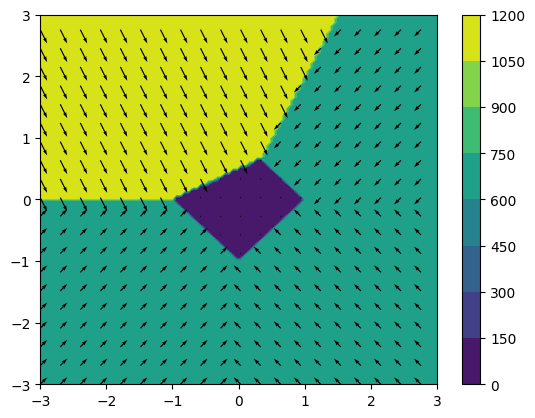

In [5]:
x = jnp.linspace(-3,3,100)
y = jnp.linspace(-3,3,100)
X,Y = jnp.meshgrid(x,y)
Z = jnp.stack([X,Y], axis=-1)
Z = Z.reshape(-1,2)
Z = log_polytope_fn_score(0., Z, jnp.array([[1.,0.],[1.,1.], [1.,-1.], [-1.,2.], [-1.,-1.]]))
Z = Z.reshape(100,100, 2)
# 2d vector field
plt.contourf(X,Y,jnp.linalg.norm(Z, axis=-1))
plt.colorbar()
plt.quiver(X[::5,::5],Y[::5,::5],Z[::5,::5,0],Z[::5,::5,1])